<a href="https://colab.research.google.com/github/SC1DR-OFFICIAL/ClientRetentionAI/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D1%87%D0%B0_2_%D0%9E%D0%B1%D0%BD%D0%B0%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B1%D0%BE%D0%BB%D0%B5%D0%B7%D0%BD%D0%B8_%D0%BF%D0%B0%D1%80%D0%BA%D0%B8%D0%BD%D1%81%D0%BE%D0%BD%D0%B0_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [93]:
# Загрузка файла в Google Colab
from google.colab import files

# Загрузка файла из локального хранилища
uploaded = files.upload()

# Чтение CSV-файла
file_name = list(uploaded.keys())[0]
data = pd.read_csv(file_name)

Saving parkinsons.data to parkinsons (3).data


In [95]:
# Проверка на пропущенные значения
print(data.isnull().sum())

# Отделение меток от признаков
X = data.drop(['status', 'name'], axis=1)  # 'status' - метка, 'name' - не нужен
y = data['status']

# Нормализация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64


In [96]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [97]:
# Инициализация модели
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Обучение модели
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:10:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [98]:
# Предсказания на тестовой выборке
y_pred = model.predict(X_test)

# Оценка точности
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели: {accuracy * 100:.2f}%')

# Дополнительные метрики
print(classification_report(y_test, y_pred))

Точность модели: 94.87%
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



## Улучшим модель

1. Используем GridSearchCV для подбора гиперпараметров
2.  Решение проблемы дисбаланса с помощью SMOTE
SMOTE (Synthetic Minority Oversampling Technique) создает синтетические образцы для менее представленного класса, улучшая балансировку данных.
Это помогает модели обучиться на более сбалансированном наборе данных, избегая перекоса в сторону более представленного класса.
3. Кросс-валидация показала стабильные результаты на 10 разбиениях данных, что подтверждает, что модель обобщает данные, а не просто запоминает их.

In [115]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Чтение CSV-файла
data = pd.read_csv('parkinsons.data')

# Отделение меток от признаков
X = data.drop(['status', 'name'], axis=1)  # 'status' - метка, 'name' - не нужен
y = data['status']

# Нормализация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Решение проблемы дисбаланса классов с помощью SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# Определение гиперпараметров для поиска
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Инициализация GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss'),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1
)

# Обучение модели с использованием поиска
grid_search.fit(X_train, y_train)

# Лучшая модель и параметры
best_model = grid_search.best_estimator_
print(f"Лучшие параметры: {grid_search.best_params_}")

# Кросс-валидация
scores = cross_val_score(best_model, X_resampled, y_resampled, cv=10, scoring='accuracy')
print(f'Средняя точность на кросс-валидации: {scores.mean() * 100:.2f}%')

# Оценка на тестовой выборке
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели на тестовой выборке: {accuracy * 100:.2f}%')


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50, 'subsample': 1.0}
Средняя точность на кросс-валидации: 93.91%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        29

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59

Точность модели на тестовой выборке: 100.00%


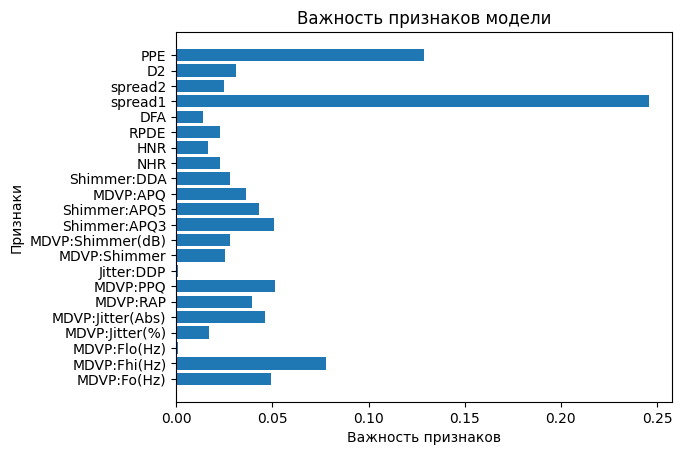

In [116]:
import matplotlib.pyplot as plt

feature_importances = best_model.feature_importances_
plt.barh(X.columns, feature_importances)
plt.xlabel("Важность признаков")
plt.ylabel("Признаки")
plt.title("Важность признаков модели")
plt.show()
